In [1]:
import webdataset as wds
url = "./data/imagenet-test.tar"
pil_dataset = wds.WebDataset(url, shardshuffle=False).decode()

In [2]:
for i in pil_dataset:
    print(i)
    break

{'__key__': 'sample000000', '__url__': './data/imagenet-test.tar', 'pred_image.pyd': tensor([[[[0.9216, 0.9216, 0.9216,  ..., 0.6235, 0.6471, 0.6471],
          [0.9216, 0.9216, 0.9216,  ..., 0.6235, 0.6471, 0.6471],
          [0.9216, 0.9216, 0.9216,  ..., 0.6196, 0.6431, 0.6431],
          ...,
          [0.1333, 0.1333, 0.1294,  ..., 0.5020, 0.5020, 0.5020],
          [0.0941, 0.0941, 0.0941,  ..., 0.5216, 0.5176, 0.5176],
          [0.0941, 0.0941, 0.0941,  ..., 0.5216, 0.5176, 0.5176]],

         [[0.7451, 0.7451, 0.7451,  ..., 0.4510, 0.4706, 0.4706],
          [0.7451, 0.7451, 0.7451,  ..., 0.4510, 0.4706, 0.4706],
          [0.7490, 0.7490, 0.7490,  ..., 0.4510, 0.4667, 0.4667],
          ...,
          [0.0863, 0.0863, 0.0824,  ..., 0.2510, 0.2314, 0.2314],
          [0.0627, 0.0627, 0.0627,  ..., 0.3020, 0.2784, 0.2784],
          [0.0627, 0.0627, 0.0627,  ..., 0.3020, 0.2784, 0.2784]],

         [[0.6157, 0.6157, 0.6157,  ..., 0.2941, 0.3098, 0.3098],
          [0.6157, 0.61

In [2]:
import wids

bucket = "https://storage.googleapis.com/webdataset/fake-imagenet/imagenet-train.json"

dataset = wids.ShardListDataset(bucket)
sample = dataset[1900]

https://storage.googleapis.com/webdataset/fake-ima base: https://storage.googleapis.com/webdataset/fake-imagenet name: imagenet-train nfiles: 1282 nbytes: 31242280960 samples: 128200 cache: /tmp/_wids_cache


In [6]:
print(sample[".cls"])

2


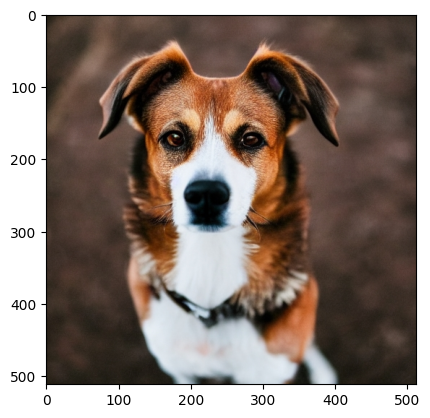

In [7]:
import matplotlib.pyplot as plt

plt.imshow(sample[".jpg"])

In [1]:
from utils.data_loader_imagenet import get_cluster_random_loader

training_loader = get_cluster_random_loader(
    root="/Volumes/DFKI117/imagenet-train2.msgpack", batch_size=16, num_classes=5, num_samples=10000, num_images=5, mini=False, num_workers=0, ratio=0.05)

100%|██████████| 1256947/1256947 [01:16<00:00, 16393.83it/s]


In [2]:
training_loader.dataset.build_image_index()

In [3]:
training_loader.dataset.build_image_index()

In [ ]:
import gc
gc.collect()

0

In [ ]:
import torch

torch.cuda.empty_cache()  # Clears unused memory
torch.cuda.ipc_collect()  # Collects and reclaims GPU memory

In [3]:
for batch_idx, (images, labels, pred_image, pred_label) in enumerate(training_loader):
    print(batch_idx)
    print(images.shape)
    if batch_idx == 0:
        break

0
torch.Size([16, 25, 3, 224, 224])


In [4]:
import torch.utils.benchmark as benchmark

timer = benchmark.Timer(
    stmt="for batch in dataloader: pass",
    globals={"dataloader": training_loader}
)

In [5]:
from torchvision.datasets import ImageNet

dataset = ImageNet(root="/Volumes/DFKI117/inet", split="train")

In [14]:
import numpy as np
sample = dataset[0]
img = np.array(sample[0])

In [1]:
from torchvision.datasets import ImageFolder

inet21k = ImageFolder(root="/Volumes/DFKI117/inet21k/imagenet21k_resized/imagenet21k_train")

In [14]:
sample = inet21k[1]
print(sample)

(<PIL.Image.Image image mode=RGB size=224x224 at 0x3BDC666F0>, 0)


In [10]:
idx_to_class = {v: k for k, v in dataset.wnid_to_idx.items()}

In [12]:
test_idx = [87, 155, 178, 181, 199, 217, 284, 321,
                   452, 469, 483, 541, 574, 753, 777, 788, 826, 927, 946]

test_classes = [idx_to_class[idx] for idx in test_idx]
print(test_classes)

['n01817953', 'n02086240', 'n02092339', 'n02093647', 'n02097298', 'n02102040', 'n02123597', 'n02276258', 'n02869837', 'n02939185', 'n02980441', 'n03249569', 'n03445777', 'n04040759', 'n04141327', 'n04200800', 'n04328186', 'n07613480', 'n07730033']


In [16]:
inet21k_test_idx = [inet21k.class_to_idx[cls] for cls in test_classes]

In [19]:
print(inet21k_test_idx)

[895, 1387, 1415, 1420, 1445, 1472, 1572, 1776, 2872, 3071, 3193, 3809, 4259, 5598, 5855, 5987, 6299, 7282, 7523]


In [ ]:
from simplejpeg import decode_jpeg_header, decode_jpeg, encode_jpeg
from PIL import Image
from PIL import UnidentifiedImageError
import io
import gzip

def encode_img(img, quality=85, short_side=375, long_side=500, colorsubsampling='422'):
    target_size = 3 * short_side * long_side
    # bio = io.BytesIO(data)
    im = np.array(img)
    colorspace = 'RGB'  # converted to RGB guaranteed
    compress = True  # force compression since simplejpeg failed
    # if images are CMYK or
    if colorspace == 'CMYK' or compress:
        # for CMYK or non-JPEG images,
        # quality might not be given, so assume 99
        if quality is None:
            quality = 98
        # default to subsampling 422
        # use full color resolution for small images
        # or if compression is disabled,
        # i.e. for CMYK images or if simplejpeg failed to decode
        if not compress or im.size <= 0.5*target_size:
            colorsubsampling = '444'
        # downscale large images
        if im.size > target_size*1.5:
            h, w = im.shape[:2]
            s = max(h, w)
            r = long_side/s
            h, w = int(round(r*h)), int(round(r*w))
            pil = Image.fromarray(im, 'RGB')
            im = np.array(pil.resize((w, h), resample=Image.LANCZOS))
        return encode_jpeg(im, quality=quality, colorsubsampling=colorsubsampling)

In [40]:
encode_img(img)

b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00\x00\x01\x00\x01\x00\x00\xff\xdb\x00C\x00\x05\x03\x04\x04\x04\x03\x05\x04\x04\x04\x05\x05\x05\x06\x07\x0c\x08\x07\x07\x07\x07\x0f\x0b\x0b\t\x0c\x11\x0f\x12\x12\x11\x0f\x11\x11\x13\x16\x1c\x17\x13\x14\x1a\x15\x11\x11\x18!\x18\x1a\x1d\x1d\x1f\x1f\x1f\x13\x17"$"\x1e$\x1c\x1e\x1f\x1e\xff\xdb\x00C\x01\x05\x05\x05\x07\x06\x07\x0e\x08\x08\x0e\x1e\x14\x11\x14\x1e\x1e\x1e\x1e\x1e\x1e\x1e\x1e\x1e\x1e\x1e\x1e\x1e\x1e\x1e\x1e\x1e\x1e\x1e\x1e\x1e\x1e\x1e\x1e\x1e\x1e\x1e\x1e\x1e\x1e\x1e\x1e\x1e\x1e\x1e\x1e\x1e\x1e\x1e\x1e\x1e\x1e\x1e\x1e\x1e\x1e\x1e\x1e\x1e\x1e\xff\xc0\x00\x11\x08\x00\xfa\x00\xfa\x03\x01\x11\x00\x02\x11\x01\x03\x11\x01\xff\xc4\x00\x1f\x00\x00\x01\x05\x01\x01\x01\x01\x01\x01\x00\x00\x00\x00\x00\x00\x00\x00\x01\x02\x03\x04\x05\x06\x07\x08\t\n\x0b\xff\xc4\x00\xb5\x10\x00\x02\x01\x03\x03\x02\x04\x03\x05\x05\x04\x04\x00\x00\x01}\x01\x02\x03\x00\x04\x11\x05\x12!1A\x06\x13Qa\x07"q\x142\x81\x91\xa1\x08#B\xb1\xc1\x15R\xd1\xf0$3br\x82\t\n\x16\x17\

In [19]:
h, w = img.shape[:2]

In [21]:
from simplejpeg import encode_jpeg, decode_jpeg_header, decode_jpeg

compressed = encode_jpeg(img, quality=98, colorsubsampling='444')
original = sample[0].tobytes()

In [22]:
import sys

sys.getsizeof(compressed), sys.getsizeof(original)

(28811, 187533)

In [29]:
exclude_classes = [87, 155, 178, 181, 199, 217, 284, 321,
                   452, 469, 483, 541, 574, 753, 777, 788, 826, 927, 946]
include_classes = None

indices = []
for idx, (_, target) in enumerate(dataset.samples):
    if include_classes is not None and target not in include_classes:
        continue
    if exclude_classes is not None and target in exclude_classes:
        continue
    indices.append(idx)

In [34]:
exclude_classes = [895, 1387, 1415, 1420, 1445, 1472, 1572, 1776, 2872, 3071, 3193, 3809, 4259, 5598, 5855, 5987, 6299, 7282, 7523]
include_classes = None

indices21k = []
for idx, (_, target) in enumerate(inet21k.samples):
    if include_classes is not None and target not in include_classes:
        continue
    if exclude_classes is not None and target in exclude_classes:
        continue
    indices21k.append(idx)

In [36]:
len(indices), len(indices21k)

(1256947, 10975340)

In [21]:
from torch.utils.data import Subset
ds = Subset(dataset, indices)

In [ ]:
from datadings.writer import FileWriter

with FileWriter('/Volumes/DFKI117/imagenet-train.msgpack') as writer:
    for i, (img, label) in enumerate(ds):
        sample = {'key': str(i), 'image': img.tobytes(), 'label': label}
        writer.write(sample)

imagenet-train.msgpack exists, overwrite? [Y/n/a/?] 